# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** | Resolver lógica de consolidación y evitar datos duplicados. | *"en datos web irian las urls empleadas [...] y en datos json quiero que levante la carpeta corpus... el dataframe que me devuelve esto es correcto?"* | Me corrigió un error lógico: estaba re-ejecutando los scrapers dentro de la función de consolidación, lo que generaba datos duplicados al leer nuevamente la carpeta corpus. | Conservé la lógica de control usando una lista `urls_ya_procesadas` para evitar anexar documentos repetidos al DataFrame. | Descarté la idea de procesar YouTube y Web dentro de `unificar_corpus`. Es mejor extraer una vez y que esa función solo lea el disco. | Aprendí a modularizar el código: la adquisición pesada (scraping) debe estar separada de la lectura/consolidación (pandas). |
| **Parte 2** | Comprender entidades nombradas y solucionar salidas truncadas. | *"Pedile a la IA criterios explícitos para distinguir PER, ORG y LOC. Además, por qué al imprimir el texto me figuran 3 puntos (...)"* | Definió los criterios teóricos de spaCy. Además, me explicó que los 3 puntos no eran un error de Python, sino un límite visual de la consola de VS Code (`notebook.output.textLineLimit`). | Conservé la implementación orientada a objetos de la clase `AnalizadorCorpus` y el uso de `Counter` para extraer entidades y lemas. | Descarté usar ciclos `for` con `print()` nativo para ver salidas largas; ahora uso `pd.DataFrame` para visualizar datos sin que el IDE los recorte. | Aprendí que spaCy puede confundirse por el contexto (ej: clasificar un país como ORG si actúa políticamente) y cómo interactúa el IDE con el output. |
| **Parte 3** | Definir gráficos según el Data-Ink Ratio. | *"¿Conviene usar un WordCloud o un Barplot para mostrar frecuencias en un informe a gerencia? Justificá con el principio de Data-Ink Ratio."* | Me sugirió usar el Barplot/Lollipop, argumentando que el WordCloud usa color y tamaño arbitrarios, desperdiciando "tinta" y dificultando la precisión analítica del ojo humano. | Conservé el uso de Seaborn y Plotly (Lollipop y Barplots horizontales) con `sns.despine()` para eliminar *chart junk*. | Descarté completamente el WordCloud porque no aporta exactitud cuantitativa para la toma de decisiones. | Comprendí que los gráficos más llamativos no siempre son los más efectivos. Alineando los datos en un eje X/Y se mejora radicalmente la lectura. |
| **Parte 4** | Orquestar funciones sueltas en un solo flujo (Pipeline). | *"Armame este punto con el fin de que se interconecten los bloques de código... y necesito que reciba varias URLs de YouTube."* | Me entregó la clase `PipelineMediatico`, corrigiendo que el parámetro original solo aceptaba un string en vez de una lista de videos, y gestionando la exportación a CSV. | Conservé la arquitectura del Pipeline y el método `drop(columns=['doc'])` antes de exportar a CSV. | Descarté intentar guardar el DataFrame tal cual estaba, porque los objetos complejos de spaCy rompen la serialización al guardar en disco. | Aprendí cómo la POO (Clases) permite guardar estados y resultados pesados en memoria (RAM) para no tener que reprocesarlos a cada rato. |
| **Parte 5** | Estructurar el Dashboard interactivo con Gradio. | *"Pedile a la IA 3 layouts de estructura (Pestañas, Vertical, Acordeón) y terminame este punto relacionando la info."* | Explicó que el formato "Acordeón" exige mucha memoria a corto plazo, el "Vertical" exige mucho scroll, y las "Pestañas" separan limpiamente los contextos. | Conservé la estructura de `gr.Tab` y la función puente que permite inyectar el DataFrame exportado y el gráfico de Plotly nativamente. | Descarté que el buscador de menciones procese los textos en tiempo real; ahora busca directamente sobre `doc.sents` ya procesado en memoria. | Comprendí la importancia de reducir la "carga cognitiva" del usuario final mediante el diseño de interfaces (UI/UX) lógicas y separadas. |


In [1]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
!pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
!python -m spacy download es_core_news_lg -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install cloudscraper


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os
import trafilatura
import requests

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [4]:


# 1.1 Scraping en vivo
def extraer_noticias_web(urls):
    """Extrae el texto de una lista de URLs usando Trafilatura"""
    headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
    'Accept-Language': 'es-AR,es;q=0.9,en-US;q=0.8,en;q=0.7',
    }
    index = 0
    responses = []
    try:
        responses = list(map(lambda url : requests.get(url, headers=headers),urls))
        if responses:
            noticias = list(map(lambda respuesta: trafilatura.extract(respuesta.text, include_comments=False, include_images=False,favor_precision=True,include_tables=False),responses))
            if noticias:
                return noticias
            else:
                return "No se pudo extraer texto de la URL."
        else:
            return "No se pudo obtener la URL."
    except Exception as e:
        return f"Ocurrió un error: {e}"
    
    return noticias

In [5]:
import requests
import trafilatura
from bs4 import BeautifulSoup
import json
import os
import re
def extraer_noticias_web(urls):
    """
    Extrae el texto de una lista de URLs usando Trafilatura,
    extrae el h1 con BeautifulSoup, y guarda el resultado como JSON.
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
        'Accept-Language': 'es-AR,es;q=0.9,en-US;q=0.8,en;q=0.7',
    }
    
    # 1. Asegurarnos de que exista la carpeta corpus
    os.makedirs("corpus", exist_ok=True)
    
    noticias_guardadas = []
    
    for index, url in enumerate(urls):
        try:
            # 2. Obtener el HTML de la URL
            respuesta = requests.get(url, headers=headers)
            respuesta.raise_for_status() # Verifica que la petición fue exitosa (código 200)
            
            html_content = respuesta.text
            
            # 3. Extraer el h1 usando BeautifulSoup
            soup = BeautifulSoup(html_content, 'html.parser')
            h1_tag = soup.find('h1')
            
            if h1_tag:
                titulo = h1_tag.get_text(strip=True)
            else:
                # Si por algún motivo la página no tiene un H1, le damos un nombre alternativo
                titulo = f"Noticia_sin_H1_{index}"
                
            # 4. Extraer el contenido principal del texto usando Trafilatura
            contenido_noticia = trafilatura.extract(
                html_content, 
                include_comments=False, 
                include_images=False,
                favor_precision=True,
                include_tables=False
            )
            
            if contenido_noticia:
                # 5. Limpiar el título para usarlo como nombre de archivo válido
                nombre_archivo_limpio = re.sub(r'[\\/*?:"<>|]', "", titulo)
                ruta_archivo = os.path.join("corpus", f"{nombre_archivo_limpio}.json")
                
                # 6. Estructurar lo que vamos a guardar en el JSON
                datos_a_guardar = {
                    "url": url,
                    "titulo": titulo,
                    "texto": contenido_noticia
                }
                
                # 7. Guardar en el disco
                with open(ruta_archivo, 'w', encoding='utf-8') as archivo:
                    json.dump(datos_a_guardar, archivo, ensure_ascii=False, indent=4)
                
                noticias_guardadas.append(datos_a_guardar)
                print(f"✅ Éxito: Se guardó '{ruta_archivo}'")
            else:
                print(f"⚠️ Aviso: No se pudo extraer texto principal de {url}")
                
        except Exception as e:
            print(f"❌ Error procesando la URL {url}: {e}")
    
    # Devuelve la lista con los diccionarios por si querés usarlos en otra variable
    return noticias_guardadas
# --- EJEMPLO DE USO ---
# lista_de_urls = ["https://ejemplo.com/noticia1", "https://ejemplo.com/noticia2"]
# mis_noticias = extraer_noticias_web(lista_de_urls)

In [6]:
"""def youtube_a_texto(url: str, modelo_whisper: str = "small", idioma: str = "es", output_dir: str = "corpus") -> dict:
    # Pipeline completo: URL de YouTube -> audio -> transcripcion -> texto
    import json
    import os
    import re
    import shutil
    import whisper
    import yt_dlp

    os.makedirs(output_dir, exist_ok=True)

    if "preparar_ffmpeg" in globals():
        _, ffmpeg_dir, _ = preparar_ffmpeg()
    else:
        ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
        if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
            raise FileNotFoundError("No se encontro ffmpeg para ejecutar el pipeline completo.")
        ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
        if ffmpeg_dir not in os.environ.get("PATH", ""):
            os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    ydl_opts = {
        "format": "bestaudio/best",
        "noplaylist": True,
        "ffmpeg_location": ffmpeg_dir,
        "postprocessors": [
            {
                "key": "FFmpegExtractAudio",
                "preferredcodec": "mp3",
                "preferredquality": "192",
            }
        ],
        "outtmpl": f"{output_dir}/%(title)s.%(ext)s",
    }

    if "sanitizar_nombre_archivo" in globals():
        sanitizar = sanitizar_nombre_archivo
    else:
        def sanitizar(ruta_o_nombre: str, max_len: int = 80) -> str:
            nombre = os.path.splitext(os.path.basename(ruta_o_nombre))[0]
            invalidos = set('<>:/\\|?*') | {chr(34)}
            nombre = ''.join('_' if caracter in invalidos or ord(caracter) < 32 else caracter for caracter in nombre)
            nombre = re.sub(r'\s+', ' ', nombre).strip().rstrip('. ')
            return (nombre[:max_len] or 'transcripcion').strip()

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        titulo = info["title"]
        duracion = info["duration"]
        audio_generado = os.path.abspath(ydl.prepare_filename(info).rsplit(".", 1)[0] + ".mp3")

    print(f"Audio descargado: {titulo} ({duracion} segundos)")

    cache_modelos = globals().setdefault("_MODELOS_WHISPER", {})
    if modelo_whisper not in cache_modelos:
        cache_modelos[modelo_whisper] = whisper.load_model(modelo_whisper)
    modelo = cache_modelos[modelo_whisper]
    resultado_local = modelo.transcribe(audio_generado, language=idioma, fp16=False)
    print(f"Transcripcion completa: {len(resultado_local['segments'])} segmentos")

    nombre_base = sanitizar(audio_generado)
    ruta_txt = os.path.join(output_dir, f"{nombre_base}.txt")
    with open(ruta_txt, "w", encoding="utf-8") as archivo_txt:
        archivo_txt.write(resultado_local["text"])

    ruta_json = os.path.join(output_dir, f"{nombre_base}.json")
    with open(ruta_json, "w", encoding="utf-8") as archivo_json:
        json.dump(
            {
                "fuente": url,
                "titulo": titulo,
                "duracion_segundos": duracion,
                "idioma": resultado_local["language"],
                "texto": resultado_local["text"],
                "segmentos": [
                    {"inicio": segmento["start"], "fin": segmento["end"], "texto": segmento["text"].strip()}
                    for segmento in resultado_local["segments"]
                ],
            },
            archivo_json,
            ensure_ascii=False,
            indent=2,
        )

    return {
        "titulo": titulo,
        "duracion": duracion,
        "texto": resultado_local["text"],
        "segmentos": resultado_local["segments"],
        "archivos_generados": [audio_generado, ruta_txt, ruta_json],
    }


# Uso sugerido:
# corpus = youtube_a_texto("https://www.youtube.com/watch?v=yX2tPSjBoeU")
# print(corpus["texto"][:500])

CHOCLASO MAL
""" 

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Emilio\AppData\Local\Temp\ipykernel_14892\2929270481.py:1: SyntaxWarning: invalid escape sequence '\s'
  """def youtube_a_texto(url: str, modelo_whisper: str = "small", idioma: str = "es", output_dir: str = "corpus") -> dict:


'def youtube_a_texto(url: str, modelo_whisper: str = "small", idioma: str = "es", output_dir: str = "corpus") -> dict:\n    # Pipeline completo: URL de YouTube -> audio -> transcripcion -> texto\n    import json\n    import os\n    import re\n    import shutil\n    import whisper\n    import yt_dlp\n\n    os.makedirs(output_dir, exist_ok=True)\n\n    if "preparar_ffmpeg" in globals():\n        _, ffmpeg_dir, _ = preparar_ffmpeg()\n    else:\n        ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")\n        if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):\n            raise FileNotFoundError("No se encontro ffmpeg para ejecutar el pipeline completo.")\n        ffmpeg_dir = os.path.dirname(ruta_ffmpeg)\n        if ffmpeg_dir not in os.environ.get("PATH", ""):\n            os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")\n\n    ydl_opts = {\n        "format": "bestaudio/best",\n        "noplaylist": True,\n        "ffmpeg_location": ffmp

In [7]:
"""def main():
    urls = [
    "https://www.youtube.com/watch?v=yX2tPSjBoeU",
    "https://www.youtube.com/watch?v=ruepxLoEwoo",
    "https://www.youtube.com/watch?v=WqXr0AujesY",
    ]

    resultados = []
    errores = []

    for indice, url in enumerate(urls, start=1):
        print("\n" + "=" * 60)
        print(f"Procesando {indice}/{len(urls)}: {url}")
        print("=" * 60)
        try:
            resultado_lote = youtube_a_texto(url, modelo_whisper="small")
            resultados.append(resultado_lote)
            print(f"OK: {resultado_lote['titulo']} - {len(resultado_lote['texto'])} caracteres")
        except Exception as error:
            errores.append({"url": url, "error": str(error)})
            print(f"ERROR: {error}")

    print(f"\nResumen: {len(resultados)} exitosos, {len(errores)} errores")

    corpus_total = "\n\n---\n\n".join(resultado_lote["texto"] for resultado_lote in resultados)
    print(f"Corpus total: {len(corpus_total)} caracteres, ~{len(corpus_total.split())} palabras")
    return corpus_total




if __name__ == "__main__":
    main()
    """

'def main():\n    urls = [\n    "https://www.youtube.com/watch?v=yX2tPSjBoeU",\n    "https://www.youtube.com/watch?v=ruepxLoEwoo",\n    "https://www.youtube.com/watch?v=WqXr0AujesY",\n    ]\n\n    resultados = []\n    errores = []\n\n    for indice, url in enumerate(urls, start=1):\n        print("\n" + "=" * 60)\n        print(f"Procesando {indice}/{len(urls)}: {url}")\n        print("=" * 60)\n        try:\n            resultado_lote = youtube_a_texto(url, modelo_whisper="small")\n            resultados.append(resultado_lote)\n            print(f"OK: {resultado_lote[\'titulo\']} - {len(resultado_lote[\'texto\'])} caracteres")\n        except Exception as error:\n            errores.append({"url": url, "error": str(error)})\n            print(f"ERROR: {error}")\n\n    print(f"\nResumen: {len(resultados)} exitosos, {len(errores)} errores")\n\n    corpus_total = "\n\n---\n\n".join(resultado_lote["texto"] for resultado_lote in resultados)\n    print(f"Corpus total: {len(corpus_total)} ca

In [8]:
import json
import os
import re
import whisper
import yt_dlp

def sanitizar_nombre(nombre: str) -> str:
    """Limpia un texto eliminando caracteres inválidos para usarlo como nombre de archivo."""
    return re.sub(r'[\\/*?:"<>|]', "", nombre).strip()

def procesar_videos_youtube(urls: list, modelo_whisper: str = "small", idioma: str = "es", output_dir: str = "corpus"):
    """
    Recibe una lista de URLs, descarga el audio, lo transcribe con Whisper
    y guarda un JSON (y el MP3) nombrados con el título original del video.
    """
    os.makedirs(output_dir, exist_ok=True)
    resultados = []
    
    # 1. Cargamos el modelo Whisper una sola vez al principio (Optimiza MUCHO el tiempo)
    print(f"Cargando modelo Whisper '{modelo_whisper}'... (Esto puede demorar unos segundos)")
    modelo = whisper.load_model(modelo_whisper)
    
    for indice, url in enumerate(urls, start=1):
        print(f"\n[{indice}/{len(urls)}] Procesando: {url}")
        
        try:
            # 2. Configuración de yt_dlp para descargar solo audio como MP3
            ydl_opts = {
                "format": "bestaudio/best",
                "noplaylist": True,
                "postprocessors": [{
                    "key": "FFmpegExtractAudio",
                    "preferredcodec": "mp3",
                    "preferredquality": "192",
                }],
                # Guardamos temporalmente usando el ID del video para no tener problemas de caracteres en la descarga
                "outtmpl": f"{output_dir}/%(id)s.%(ext)s", 
                "quiet": True,
                "no_warnings": True
            }
            
            with yt_dlp.YoutubeDL(ydl_opts) as ydl:
                info = ydl.extract_info(url, download=True)
                titulo = info.get("title", f"Video_sin_titulo_{indice}")
                duracion = info.get("duration", 0)
                
                # Esta es la ruta temporal que le asignó yt-dlp
                audio_temp_path = os.path.join(output_dir, f"{info['id']}.mp3")
            
            print(f"✅ Audio descargado. Transcribiendo '{titulo}'...")
            
            # 3. Transcribir con Whisper
            resultado_whisper = modelo.transcribe(audio_temp_path, language=idioma, fp16=False)
            
            # 4. Limpiar el título para guardar los archivos definitivos
            nombre_limpio = sanitizar_nombre(titulo)
            ruta_json = os.path.join(output_dir, f"{nombre_limpio}.json")
            ruta_audio_final = os.path.join(output_dir, f"{nombre_limpio}.mp3")
            
            # 5. Generar y guardar el JSON
            datos_json = {
                "fuente": url,
                "titulo": titulo,
                "duracion_segundos": duracion,
                "idioma": resultado_whisper.get("language", idioma),
                "texto": resultado_whisper["text"],
                "segmentos": [
                    {"inicio": seg["start"], "fin": seg["end"], "texto": seg["text"].strip()}
                    for seg in resultado_whisper.get("segments", [])
                ]
            }
            
            with open(ruta_json, "w", encoding="utf-8") as archivo_json:
                json.dump(datos_json, archivo_json, ensure_ascii=False, indent=4)
                
            # 6. Renombrar el MP3 para que tenga el mismo nombre hermoso que el JSON
            if os.path.exists(audio_temp_path):
                if os.path.exists(ruta_audio_final): # Si ya existía uno viejo, lo borramos
                    os.remove(ruta_audio_final)
                os.rename(audio_temp_path, ruta_audio_final)
                
            resultados.append(datos_json)
            print(f"✅ Completado. Guardado en '{ruta_json}'")
            
        except Exception as e:
            print(f"❌ Error al procesar {url}: {e}")
            
    return resultados




In [9]:
import os
import glob
import json

def cargar_json_desde_carpeta(carpeta="corpus"):
    """
    Busca todos los archivos .json en la carpeta especificada 
    y los carga en una lista de diccionarios usando la librería nativa json.
    """
    # 1. glob.glob busca todos los archivos que coincidan con la extensión .json
    patron_busqueda = os.path.join(carpeta, "*.json")
    rutas_json = glob.glob(patron_busqueda)
    
    if not rutas_json:
        print(f"⚠️ No se encontraron archivos JSON en la carpeta '{carpeta}'.")
        return []
        
    print(f"Se encontraron {len(rutas_json)} archivos. Cargando...")
    
    corpus = []
    
    # 2. Iteramos sobre cada ruta encontrada y abrimos el archivo
    for ruta in rutas_json:
        try:
            with open(ruta, 'r', encoding='utf-8') as archivo:
                datos_json = json.load(archivo)
                corpus.append(datos_json)
                
        except Exception as e:
            print(f"❌ Error al intentar cargar {ruta}: {e}")
            
    return corpus





In [10]:
# 1.4 Consolidación
import pandas as pd

def unificar_corpus(datos_web, datos_youtube):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""
    
    # 1. Ejecutamos las extracciones
    dic_noticiasWeb = extraer_noticias_web(datos_web)
    mis_transcripciones = procesar_videos_youtube(datos_youtube)
    mi_corpus = cargar_json_desde_carpeta("corpus")
    
    # ¡FALTABA ESTO! Crear la lista vacía
    filas_estandarizadas = []
    
    # Para evitar duplicados, guardamos las URLs que ya procesamos
    urls_ya_procesadas = []
    
    # 1. Procesar datos de extracción Web
    if dic_noticiasWeb:
        for doc in dic_noticiasWeb: # ¡CORREGIDO! Antes decía datos_web
            url = doc.get('url', '')
            urls_ya_procesadas.append(url)
            
            filas_estandarizadas.append({
                'titulo_o_fuente': doc.get('titulo', doc.get('url', 'Web sin título')),
                'texto': doc.get('texto', doc.get('contenido', '')),
                'origen': 'web'
            })
            
    # 2. Procesar datos de YouTube/Audio
    if mis_transcripciones:
        for doc in mis_transcripciones:
            url = doc.get('fuente', '')
            urls_ya_procesadas.append(url)
            
            filas_estandarizadas.append({
                'titulo_o_fuente': doc.get('titulo', doc.get('fuente', 'Audio sin título')),
                'texto': doc.get('texto', ''),
                'origen': 'audio'
            })
            
    # 3. Procesar datos cargados de archivos JSON locales
    if mi_corpus:
        for doc in mi_corpus:
            url_json = doc.get('url', doc.get('fuente', ''))
            
            # ¡CLAVE! Solo lo agregamos si no es uno de los que acabamos de descargar arriba
            if url_json not in urls_ya_procesadas:
                titulo = doc.get('titulo', doc.get('title', doc.get('url', doc.get('fuente', 'JSON sin título'))))
                texto = doc.get('texto', doc.get('contenido', ''))
                
                filas_estandarizadas.append({
                    'titulo_o_fuente': titulo,
                    'texto': texto,
                    'origen': 'json'
                })
                
    # ¡CORREGIDO! Pasarle la lista al DataFrame
    df_unificado = pd.DataFrame(filas_estandarizadas)
    return df_unificado

# ---- Espacio para pruebas ----
# Probá tus funciones acá con al menos 1 url web y 1 video corto.
# df_corpus = unificar_corpus(...)

In [11]:
"""def main():
    rutas_json = []

    print(rutas_json)
    corpus = cargar_json_previo(rutas_json)
    print(len(corpus))



if __name__ == "__main__":
    main()"""

'def main():\n    rutas_json = []\n\n    print(rutas_json)\n    corpus = cargar_json_previo(rutas_json)\n    print(len(corpus))\n\n\n\nif __name__ == "__main__":\n    main()'

> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

In [12]:

import spacy

class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_lg"):
        self.df = df
        print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)
        
        # Procesamos la columna 'texto' al instanciar la clase
        print("Procesando los textos con spaCy...")
        # PASO 1: Creá una nueva columna en el DataFrame llamada 'doc' que contenga el objeto procesado por self.nlp()
        # self.df['doc'] = ...
        
    def extraer_entidades(self):
        """Devuelve las entidades agrupadas por tipo, contabilizando total de apariciones"""
        # PASO 2: Recorré los 'doc' del DataFrame y armá un diccionario o lista con las entidades halladas.
        pass

    def extraer_verbos_principales(self, n=15):
        """Devuelve los 'n' verbos lematizados más frecuentes de todo el corpus"""
        # PASO 3: Filtrá tokens que sean VERB y no sean stopwords, extraé su lema y contalos.
        pass

    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados"""
        # PASO 4: Implementá una lógica superior a la del Lab 009 (donde usamos stopwords crudas).
        # Filtrá por categorías gramaticales relevantes (NOUN, PROPN, ADJ) omitiendo puntuación y stopwords.
        pass
        
    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus"""
        # PASO 5: Calculá total de tokens, tamaño del vocabulario único (lemas) y cantidad de oraciones.
        pass

# ---- Espacio para pruebas ----
# analizador = AnalizadorCorpus(df_corpus)
# print(analizador.estadisticas_corpus())

> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

In [13]:
import spacy
import pandas as pd
from collections import Counter
class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_lg"): # Puedes cambiar a "es_core_news_sm" si el lg tarda mucho
        # Guardamos una copia del DataFrame para no modificar el original por accidente
        self.df = df.copy() 
        print(f"Cargando modelo de lenguaje '{modelo_spacy}'...")
        self.nlp = spacy.load(modelo_spacy)
        
        print("Procesando los textos con spaCy (esto puede demorar dependiendo del tamaño de tu corpus)...")
        # PASO 1: Procesamos la columna 'texto'. 
        # Usamos lambda str(x) por si acaso hay algún valor nulo o numérico que rompa spaCy.
        self.df['doc'] = self.df['texto'].apply(lambda x: self.nlp(str(x)))
        print("¡Textos procesados y guardados en la columna 'doc'!")
        
    def extraer_entidades(self):
        """Devuelve las entidades agrupadas por tipo, contabilizando total de apariciones"""
        # PASO 2: Recorré los 'doc' del DataFrame y armá un diccionario con las entidades halladas.
        entidades_por_tipo = {}
        
        for doc in self.df['doc']:
            for ent in doc.ents:
                # Si el tipo de entidad (ej: 'PER', 'ORG') no está en el diccionario, lo creamos
                if ent.label_ not in entidades_por_tipo:
                    entidades_por_tipo[ent.label_] = Counter()
                
                # Sumamos 1 a esa palabra específica dentro de su categoría
                entidades_por_tipo[ent.label_][ent.text] += 1
                
        # Para que sea más lindo de leer, convertimos los Counters a diccionarios estándar
        # y traemos solo las 10 más comunes por cada categoría
        resultado = {tipo: dict(contador.most_common(10)) for tipo, contador in entidades_por_tipo.items()}
        return resultado
    def extraer_verbos_principales(self, n=15):
        """Devuelve los 'n' verbos lematizados más frecuentes de todo el corpus"""
        # PASO 3: Filtrá tokens que sean VERB y no sean stopwords, extraé su lema y contalos.
        contador_verbos = Counter()
        
        for doc in self.df['doc']:
            for token in doc:
                # Condición: que sea verbo y NO sea una stopword
                if token.pos_ == "VERB" and not token.is_stop:
                    # Guardamos el lema en minúsculas para unificar (ej: 'Viajaremos' -> 'viajar')
                    contador_verbos[token.lemma_.lower()] += 1
                    
        return contador_verbos.most_common(n)
    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados"""
        # PASO 4: Filtrá por categorías gramaticales relevantes (NOUN, PROPN, ADJ) omitiendo puntuación y stopwords.
        contador_palabras = Counter()
        categorias_buscadas = ["NOUN", "PROPN", "ADJ"]
        
        for doc in self.df['doc']:
            for token in doc:
                if token.pos_ in categorias_buscadas and not token.is_stop and not token.is_punct:
                    # Guardamos el lema. Los nombres propios (PROPN) los dejamos con su mayúscula, 
                    # pero los adjetivos y sustantivos los pasamos a minúscula.
                    if token.pos_ == "PROPN":
                        lema = token.lemma_
                    else:
                        lema = token.lemma_.lower()
                        
                    contador_palabras[lema] += 1
                    
        return contador_palabras.most_common(n)
        
    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus"""
        # PASO 5: Calculá total de tokens, tamaño del vocabulario único (lemas) y cantidad de oraciones.
        total_tokens = 0
        total_oraciones = 0
        lemas_unicos = set() # Usamos un 'set' matemático porque no permite duplicados
        
        for doc in self.df['doc']:
            # len(doc) nos da el total de tokens de este documento
            total_tokens += len(doc)
            
            # doc.sents es un generador de oraciones, lo convertimos a lista para contarlo
            total_oraciones += len(list(doc.sents))
            
            for token in doc:
                # Para el vocabulario, ignoramos espacios vacíos y signos de puntuación
                if not token.is_punct and not token.is_space:
                    lemas_unicos.add(token.lemma_.lower())
                    
        return {
            "Total de documentos": len(self.df),
            "Total de oraciones": total_oraciones,
            "Total de tokens": total_tokens,
            "Vocabulario (lemas únicos)": len(lemas_unicos)
        }

In [14]:
# --- 1. Definimos las listas de URLs que usaste ---
"""mis_urls_web = [
    "https://es.wikipedia.org/wiki/Procesamiento_de_lenguajes_naturales"
]
mis_urls_youtube = [
    "https://www.youtube.com/watch?v=yX2tPSjBoeU"
]

# --- 2. Unificamos el corpus ---
print("1. Unificando el corpus...")
df_corpus = unificar_corpus(mis_urls_web, mis_urls_youtube)
print(f"   Corpus unificado con {len(df_corpus)} documentos.")

# --- 3. Ejecutamos el análisis pesado (spaCy) UNA SOLA VEZ ---
print("\n2. Iniciando Analizador con spaCy (esto puede demorar)...")
# Nota: Si "es_core_news_lg" tarda muchísimo, cámbialo a "es_core_news_sm"
analizador = AnalizadorCorpus(df_corpus, modelo_spacy="es_core_news_lg") 

# --- 4. Extraemos y guardamos los resultados en VARIABLES ---
# Guardamos todo en estas 4 variables. ¡Estas son las que usarás en la Parte 3 (Gráficos)!
print("\n3. Extrayendo métricas y guardando en variables...")

mis_estadisticas = analizador.estadisticas_corpus()
mis_entidades = analizador.extraer_entidades()
mis_verbos = analizador.extraer_verbos_principales(n=15)
mis_palabras_clave = analizador.extraer_palabras_clave(n=20)

print("\n✅ ¡Análisis completado! La información está guardada en la memoria RAM.")"""


'mis_urls_web = [\n    "https://es.wikipedia.org/wiki/Procesamiento_de_lenguajes_naturales"\n]\nmis_urls_youtube = [\n    "https://www.youtube.com/watch?v=yX2tPSjBoeU"\n]\n\n# --- 2. Unificamos el corpus ---\nprint("1. Unificando el corpus...")\ndf_corpus = unificar_corpus(mis_urls_web, mis_urls_youtube)\nprint(f"   Corpus unificado con {len(df_corpus)} documentos.")\n\n# --- 3. Ejecutamos el análisis pesado (spaCy) UNA SOLA VEZ ---\nprint("\n2. Iniciando Analizador con spaCy (esto puede demorar)...")\n# Nota: Si "es_core_news_lg" tarda muchísimo, cámbialo a "es_core_news_sm"\nanalizador = AnalizadorCorpus(df_corpus, modelo_spacy="es_core_news_lg") \n\n# --- 4. Extraemos y guardamos los resultados en VARIABLES ---\n# Guardamos todo en estas 4 variables. ¡Estas son las que usarás en la Parte 3 (Gráficos)!\nprint("\n3. Extrayendo métricas y guardando en variables...")\n\nmis_estadisticas = analizador.estadisticas_corpus()\nmis_entidades = analizador.extraer_entidades()\nmis_verbos = anal

## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
(*Para un informe dirigido a la toma de decisiones, conviene usar definitivamente un Barplot (Gráfico de barras) y NO un WordCloud. Aplicando el principio de Data-Ink Ratio de Tufte, un WordCloud desperdicia demasiada "tinta" en adornos estéticos: usa colores arbitrarios, rotaciones que dificultan la lectura y tamaños de fuente cuyas áreas el ojo humano no sabe calcular con precisión. En cambio, un Barplot maximiza el Data-Ink Ratio al alinear todos los datos en una línea base común. Permite al ojo comparar magnitudes de forma exacta y rápida, y el texto es horizontal y legible, lo que evita cargas cognitivas innecesarias a la gerencia.*)

In [17]:
# Configuración base de accesibilidad visual
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE = '#b0b0b0'

def visualizar_origen(df):
    """Genera un barplot con el origen de los datos o las secciones"""
    # PASO 1: Generá un barplot horizontal orientado a objetos (fig, ax) usando Seaborn.
    # Aplicá el COLOR_ACENTO a la barra principal (la de mayor count).
    # Despintá los bordes molestos con sns.despine()
    pass

def visualizar_palabras_clave_lollipop(palabras_clave):
    """Genera un Lollipop Chart de las palabras clave lematizadas"""
    # PASO 2: Construí el gráfico estructurado (Lollipop) para las palabras clave extraídas en la Parte 2.
    # Recordá que el lollipop se arma combinando ax.hlines y ax.plot.
    pass

def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes"""
    # PASO 3: Resolvelo utilizando go.Bar y devolvé el objeto figura (fig) de Plotly
    # para usarlo posteriormente en Gradio.
    pass

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import pandas as pd

# Configuración base de accesibilidad visual
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE = '#b0b0b0'

def visualizar_origen(df):
    """Genera un barplot con el origen de los datos o las secciones"""
    # 1. Contamos cuántos documentos hay de cada origen
    conteo = df['origen'].value_counts()
    
    # 2. Preparamos el canvas orientado a objetos
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # 3. Aplicamos la regla visual: color acento solo al más grande (el primero)
    colores = [COLOR_ACENTO] + [COLOR_BASE] * (len(conteo) - 1)
    
    # 4. Generamos el gráfico
    sns.barplot(x=conteo.values, y=conteo.index, palette=colores, ax=ax, hue=conteo.index, legend=False)
    
    # 5. Formato y limpieza de chart junk
    ax.set_title("Distribución del Corpus por Origen", pad=15, fontweight='bold')
    ax.set_xlabel("Cantidad de Documentos")
    ax.set_ylabel("")
    
    sns.despine(left=True, bottom=False) # Removemos bordes innecesarios
    plt.tight_layout()
    plt.show()

def visualizar_palabras_clave_lollipop(palabras_clave):
    """Genera un Lollipop Chart de las palabras clave lematizadas"""
    # 1. Convertimos la lista de tuplas que nos dio spaCy a DataFrame
    df_pal = pd.DataFrame(palabras_clave, columns=["Palabra", "Frecuencia"])
    
    # 2. Ordenamos de menor a mayor para que en el eje Y horizontal las barras mayores queden arriba
    df_pal = df_pal.sort_values(by="Frecuencia", ascending=True)
    
    # 3. Preparamos el canvas
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 4. Lollipop = Líneas horizontales (hlines) + Puntos (plot)
    # Las líneas van en color base, los puntos en color acento para destacar
    ax.hlines(y=df_pal['Palabra'], xmin=0, xmax=df_pal['Frecuencia'], color=COLOR_BASE, alpha=0.7, linewidth=2)
    ax.plot(df_pal['Frecuencia'], df_pal['Palabra'], "o", markersize=8, color=COLOR_ACENTO)
    
    # 5. Formato
    ax.set_title("Top Palabras Clave del Corpus (Lollipop Chart)", pad=15, fontweight='bold')
    ax.set_xlabel("Frecuencia de aparición")
    ax.set_ylabel("")
    
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.show()

def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes"""
    # 1. 'entidades_dict' es un diccionario complejo. Vamos a aplanarlo para extraer las entidades
    # principales (PERsonas, ORGanizaciones, LOCalizaciones).
    datos_planos = []
    for tipo, entidades in entidades_dict.items():
        if tipo in ["PER", "ORG", "LOC"]: 
            for entidad, freq in entidades.items():
                datos_planos.append({"Entidad": entidad, "Frecuencia": freq, "Tipo": tipo})
                
    df_ent = pd.DataFrame(datos_planos)
    
    # Tomamos el TOP 15 general para que el gráfico no se vuelva ilegible
    df_ent = df_ent.sort_values(by="Frecuencia", ascending=False).head(15)
    df_ent = df_ent.sort_values(by="Frecuencia", ascending=True) # Para que quede de mayor a menor en horizontal
    
    # 2. Construimos la figura en Plotly
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        y=df_ent["Entidad"],
        x=df_ent["Frecuencia"],
        orientation='h',
        marker=dict(
            color=COLOR_ACENTO,
        ),
        # Esto configura la ventanita interactiva que sale al pasar el mouse
        text=df_ent["Tipo"], 
        hovertemplate='<b>%{y}</b><br>Apariciones: %{x}<br>Tipo (spaCy): %{text}<extra></extra>'
    ))
    
    # 3. Layout profesional, estilo minimalista ('plotly_white')
    fig.update_layout(
        title="Top 15 Entidades Nombradas (Interactivo)",
        xaxis_title="Frecuencia",
        yaxis_title="",
        template="plotly_white",
        margin=dict(l=20, r=20, t=50, b=20)
    )
    
    # IMPORTANTE: Devolvemos la figura como pide el Paso 3 (para Gradio)
    return fig


## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [20]:
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None
        
    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
        # PASO 1: Orquestá las llamadas a las funciones de la Parte 1.
        
        # PASO 2: Instanciá AnalizadorCorpus y derivale el DataFrame resultante para procesar.

        print("Pipeline ejecutado exitosamente.")
        
    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="estadisticas.json"):
        """Exporta el dataframe y un JSON analítico"""
        # PASO 3: Persistí self.df como CSV.
        # ¡OJO! La columna 'doc' de spaCy no es serializable, deberías dropearla o extraer sus textos antes de guardar.
        
        # PASO 4: Persistí las estadísticas y el diccionario de entidades devueltas por el Analizador como JSON local.
        pass

# ---- Espacio para pruebas ----
# pipeline = PipelineMediatico(urls_web=["..."], url_audio="...")
# pipeline.ejecutar_pipeline()
# pipeline.generar_reporte_y_exportar()

In [21]:
import json
import pandas as pd

class PipelineMediatico:
    # 1. Cambiamos el nombre del parámetro a 'urls_youtube'
    def __init__(self, urls_web=None, urls_youtube=None, ruta_json="corpus"):
        self.urls_web = urls_web or []
        
        # 2. Ahora aseguramos que se guarde como lista
        if isinstance(urls_youtube, str):
            self.urls_youtube = [urls_youtube]
        else:
            self.urls_youtube = urls_youtube or []
            
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None
        
    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
        print("INICIANDO PIPELINE DE PROCESAMIENTO...")
        
        # PASO 1: Orquestá las llamadas a las funciones de la Parte 1.
        print("\n>> FASE 1: Unificando Corpus (Web, Audio y JSON local)...")
        # Le pasamos self.urls_youtube
        self.df = unificar_corpus(self.urls_web, self.urls_youtube)
        
        if self.df.empty:
            print("❌ Error: El DataFrame está vacío. Revisa tus rutas o URLs.")
            return

        # PASO 2: Instanciá AnalizadorCorpus
        print("\n>> FASE 2: Procesamiento de Lenguaje Natural (NLP)...")
        self.analizador = AnalizadorCorpus(self.df, modelo_spacy="es_core_news_lg") 

        print("\n✅ Pipeline ejecutado exitosamente.")
        
    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_archivo_json="estadisticas.json"):
        """Exporta el dataframe y un JSON analítico"""
        
        if self.analizador is None:
            print("❌ Error: Debes ejecutar el pipeline primero.")
            return
            
        # PASO 3: Persistí self.df como CSV.
        print(f"\n>> FASE 3: Exportando DataFrame a '{ruta_csv}'...")
        df_a_exportar = self.analizador.df.copy()
        
        if 'doc' in df_a_exportar.columns:
            df_a_exportar = df_a_exportar.drop(columns=['doc'])
            
        df_a_exportar.to_csv(ruta_csv, index=False, encoding='utf-8')
        print("   ¡CSV guardado!")
        
        # PASO 4: Persistí las estadísticas y entidades
        print(f"\n>> FASE 4: Exportando analíticas a '{ruta_archivo_json}'...")
        datos_json = {
            "estadisticas_generales": self.analizador.estadisticas_corpus(),
            "entidades": self.analizador.extraer_entidades(),
            "verbos_principales": dict(self.analizador.extraer_verbos_principales()),
            "palabras_clave": dict(self.analizador.extraer_palabras_clave())
        }
        
        with open(ruta_archivo_json, 'w', encoding='utf-8') as f:
            json.dump(datos_json, f, ensure_ascii=False, indent=4)
            
        print("   ¡JSON guardado!")
        print("\n🎉 Reportes generados con éxito.")



In [22]:
# 1. Coloca varias URLs web
urls_noticias = [
    "https://es.wikipedia.org/wiki/Procesamiento_de_lenguajes_naturales",
    "https://es.wikipedia.org/wiki/Inteligencia_artificial",
    "https://www.forbesargentina.com/negocios/la-historia-detras-sucesor-galperin-asi-fue-carrera-silenciosa-ariel-szarfsztejn-cima-mercado-libre-n84159"
]

# 2. ¡Coloca varias URLs de YouTube!
mis_videos_youtube = [
    "https://www.youtube.com/shorts/eEPB1waaW_s",
    "https://www.youtube.com/shorts/HYy6D6JLtaI",
    "https://www.youtube.com/shorts/KYEhvfFfoVU"
]

# 3. Instanciamos el Pipeline (usando el nuevo parámetro 'urls_youtube')
pipeline = PipelineMediatico(urls_web=urls_noticias, urls_youtube=mis_videos_youtube)

# 4. Lo ejecutamos
pipeline.ejecutar_pipeline()
pipeline.generar_reporte_y_exportar()


INICIANDO PIPELINE DE PROCESAMIENTO...

>> FASE 1: Unificando Corpus (Web, Audio y JSON local)...
✅ Éxito: Se guardó 'corpus\Procesamiento de lenguajes naturales.json'
✅ Éxito: Se guardó 'corpus\Inteligencia artificial.json'
✅ Éxito: Se guardó 'corpus\La historia detrás del sucesor de Galperin así fue la carrera silenciosa de Ariel Szarfsztejn hasta la cima de Mercado Libre.json'
Cargando modelo Whisper 'small'... (Esto puede demorar unos segundos)

[1/3] Procesando: https://www.youtube.com/shorts/eEPB1waaW_s
✅ Audio descargado. Transcribiendo 'La durs realidad de los videos motivacionales #motivacion #usainbolt #desarrollopersonal #exito'...
✅ Completado. Guardado en 'corpus\La durs realidad de los videos motivacionales #motivacion #usainbolt #desarrollopersonal #exito.json'

[2/3] Procesando: https://www.youtube.com/shorts/HYy6D6JLtaI
✅ Audio descargado. Transcribiendo 'Esto te hará Reflexionar sobre tu Vida #motivacion #reflexion #gumball #desarrollopersonal #exito'...
✅ Completado.

INICIANDO PIPELINE DE PROCESAMIENTO...

>> FASE 1: Unificando Corpus (Web, Audio y JSON local)...
✅ Éxito: Se guardó 'corpus\Procesamiento de lenguajes naturales.json'
✅ Éxito: Se guardó 'corpus\Inteligencia artificial.json'
✅ Éxito: Se guardó 'corpus\La historia detrás del sucesor de Galperin así fue la carrera silenciosa de Ariel Szarfsztejn hasta la cima de Mercado Libre.json'
Cargando modelo Whisper 'small'... (Esto puede demorar unos segundos)

[1/3] Procesando: https://www.youtube.com/shorts/eEPB1waaW_s
✅ Audio descargado. Transcribiendo 'La durs realidad de los videos motivacionales #motivacion #usainbolt #desarrollopersonal #exito'...
✅ Completado. Guardado en 'corpus\La durs realidad de los videos motivacionales #motivacion #usainbolt #desarrollopersonal #exito.json'

[2/3] Procesando: https://www.youtube.com/shorts/HYy6D6JLtaI
✅ Audio descargado. Transcribiendo 'Esto te hará Reflexionar sobre tu Vida #motivacion #reflexion #gumball #desarrollopersonal #exito'...
✅ Completado.

,Verbo,Frecuencia
0,utilizar,27
1,desarrollar,26
2,permitir,24
3,aprender,20
4,mejorar,15
5,tomar,15
6,resolver,14
7,incluir,14
8,ayudar,14
9,generar,13



--- TOP 20 PALABRAS CLAVE ---


,Palabra,Frecuencia
0,artificial,167
1,inteligencia,152
2,IA,117
3,humano,97
4,consultado,76
5,sistema,68
6,lenguaje,48
7,aprendizaje,48
8,dato,48
9,robot,46



--- ENTIDADES ENCONTRADAS ---

>> CATEGORÍA: ORG (Total únicas: 10)
     - IA: 59 veces
     - Inteligencia: 11 veces
     - PLN: 10 veces
     - ACM: 7 veces
     - Google: 6 veces

>> CATEGORÍA: MISC (Total únicas: 10)
     - Consultado: 45 veces
     - Norvig: 22 veces
     - IA: 14 veces
     - Inteligencia Artificial: 13 veces
     - ChatGPT: 9 veces

>> CATEGORÍA: PER (Total únicas: 10)
     - Russell: 21 veces
     - Szarfsztejn: 14 veces
     - Goebel: 10 veces
     - Galperin: 9 veces
     - Turing: 7 veces

>> CATEGORÍA: LOC (Total únicas: 10)
     - Mercado Libre: 26 veces
     - Szarfsztejn: 8 veces
     - Mackworth: 6 veces
     - Mercado Pago: 6 veces
     - Archivado: 5 veces

--- GENERANDO GRÁFICOS ---


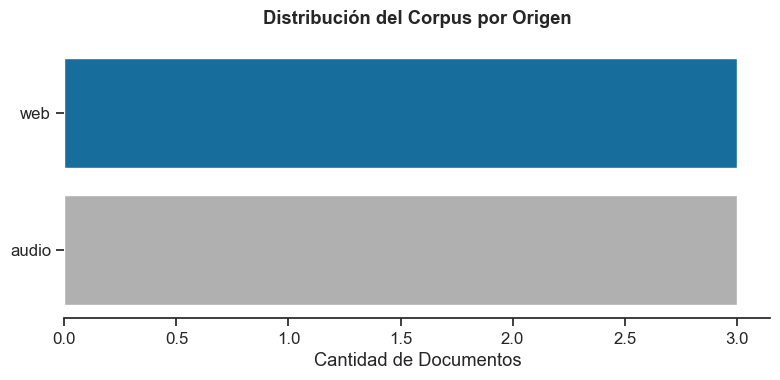

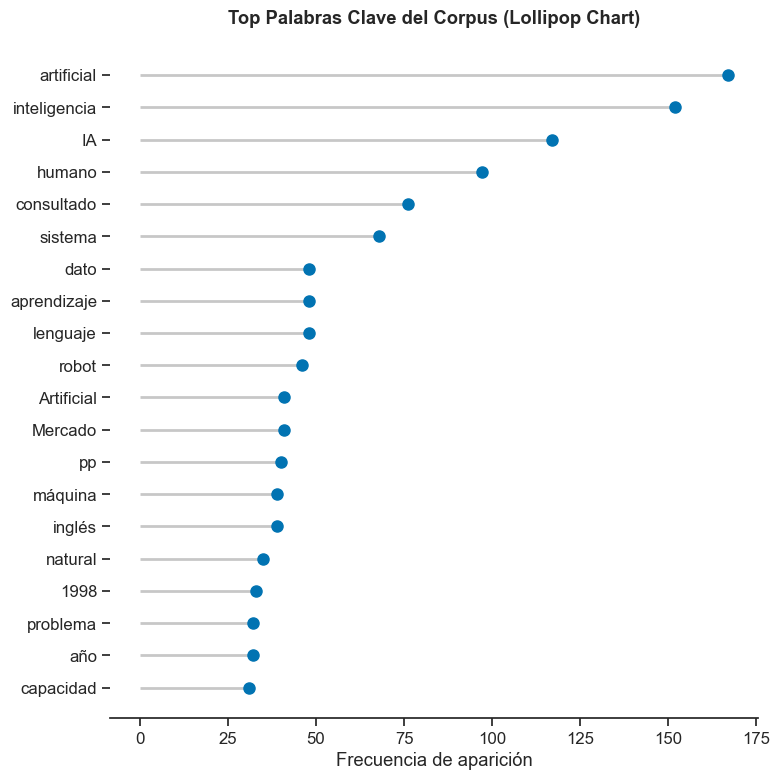

In [24]:
import pandas as pd

# 1. Coloca varias URLs web
urls_noticias = [
    "https://es.wikipedia.org/wiki/Procesamiento_de_lenguajes_naturales",
    "https://es.wikipedia.org/wiki/Inteligencia_artificial",
    "https://www.forbesargentina.com/negocios/la-historia-detras-sucesor-galperin-asi-fue-carrera-silenciosa-ariel-szarfsztejn-cima-mercado-libre-n84159"
]

# 2. Coloca varias URLs de YouTube
mis_videos_youtube = [
    "https://www.youtube.com/shorts/eEPB1waaW_s",
    "https://www.youtube.com/shorts/HYy6D6JLtaI",
    "https://www.youtube.com/shorts/KYEhvfFfoVU"
]

# 3. Instanciamos el Pipeline
pipeline = PipelineMediatico(urls_web=urls_noticias, urls_youtube=mis_videos_youtube)

# 4. Lo ejecutamos y exportamos
pipeline.ejecutar_pipeline()
pipeline.generar_reporte_y_exportar()

# --- NUEVO PASO 5: EXTRAER LAS VARIABLES DEL PIPELINE ---
# Rescatamos los resultados que están escondidos dentro del analizador del pipeline
df_corpus = pipeline.df
mis_estadisticas = pipeline.analizador.estadisticas_corpus()
mis_entidades = pipeline.analizador.extraer_entidades()
mis_verbos = pipeline.analizador.extraer_verbos_principales(n=15)
mis_palabras_clave = pipeline.analizador.extraer_palabras_clave(n=20)


# --- 6. IMPRIMIR TEXTOS ---
print("📊 ESTADÍSTICAS DEL CORPUS:")
for clave, valor in mis_estadisticas.items():
    print(f"   - {clave}: {valor}")

print("\n--- TOP 15 VERBOS MÁS USADOS ---")
df_verbos = pd.DataFrame(mis_verbos, columns=["Verbo", "Frecuencia"])
display(df_verbos)

print("\n--- TOP 20 PALABRAS CLAVE ---")
df_palabras = pd.DataFrame(mis_palabras_clave, columns=["Palabra", "Frecuencia"])
display(df_palabras)

print("\n--- ENTIDADES ENCONTRADAS ---")
for tipo_entidad, palabras in mis_entidades.items():
    if tipo_entidad in ["PER", "ORG", "LOC", "MISC"]: 
        print(f"\n>> CATEGORÍA: {tipo_entidad} (Total únicas: {len(palabras)})")
        for palabra, cantidad in list(palabras.items())[:5]: 
            print(f"     - {palabra}: {cantidad} veces")

# --- 7. RENDERIZAR GRÁFICOS ---
print("\n--- GENERANDO GRÁFICOS ---")

# Gráfico 1: Origen
visualizar_origen(df_corpus)

# Gráfico 2: Palabras Clave
visualizar_palabras_clave_lollipop(mis_palabras_clave)

# Gráfico 3: Entidades Interactivos
fig_plotly = visualizar_entidades_plotly(mis_entidades)
fig_plotly.show()


> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [ ]:
# PASO 1: Diseñá el bloque principal de gr.Blocks() interactuando con los métodos de la clase AnalizadorCorpus.
# Sugerencia: Utilizá pestañas (gr.Tab) para separar "Métricas Generales" de "Filtros e Interacción".

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# Explorador de Agenda Mediática")
    
    with gr.Tab("Panorama y Métricas"):
        # Incluí acá la visualización de frecuencias y orígenes, acompañando un gr.DataFrame con métricas generales.
        pass
        
    with gr.Tab("Explorador de Entidades"):
        # Desarrollá un textbox para ingresar una entidad y un botón que dispare
        # un filtrado, mostrando sólo las oraciones dentro de los textos donde se mencionó dicha entidad.
        pass

# Descomentá la siguiente línea cuando el bloque esté terminado
# dashboard_medios.launch()

C:\Users\Emilio\AppData\Local\Temp\ipykernel_28416\2256453203.py:4: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


In [25]:
import gradio as gr
import pandas as pd

# --- FUNCIONES PUENTE PARA GRADIO ---

def obtener_df_estadisticas():
    """Convierte el diccionario de estadísticas del analizador en un DataFrame para Gradio"""
    stats = pipeline.analizador.estadisticas_corpus()
    return pd.DataFrame(list(stats.items()), columns=["Métrica", "Valor"])

def buscar_oraciones_entidad(entidad_buscada):
    """Busca una entidad en todas las oraciones del corpus y devuelve el texto completo"""
    if not entidad_buscada.strip():
        return "Por favor ingresa una entidad para buscar."
        
    oraciones_encontradas = []
    
    # Recorremos la columna 'doc' (que tiene los objetos procesados por spaCy)
    for doc in pipeline.analizador.df['doc']:
        # spaCy ya separó el texto en oraciones en 'doc.sents'
        for oracion in doc.sents:
            # Si el texto buscado está dentro de esta oración específica
            if entidad_buscada.lower() in oracion.text.lower():
                # Agregamos la oración limpia a nuestra lista
                oraciones_encontradas.append(f"📌 {oracion.text.strip()}")
                
    if not oraciones_encontradas:
        return f"No se encontraron menciones en contexto para la entidad: '{entidad_buscada}'"
        
    # Unimos todas las oraciones con un doble salto de línea para que sea fácil de leer
    return "\n\n".join(oraciones_encontradas)


# --- INTERFAZ GRÁFICA ---

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# 📰 Explorador de Agenda Mediática (TPI 1)")
    
    # PESTAÑA 1: Estado Estático / Panorama
    with gr.Tab("Panorama y Métricas"):
        with gr.Row():
            with gr.Column(scale=1):
                gr.Markdown("### Estadísticas Generales")
                # Pasamos la tabla de estadísticas
                gr.DataFrame(value=obtener_df_estadisticas(), interactive=False)
                
            with gr.Column(scale=2):
                gr.Markdown("### Top 15 Entidades Nombradas")
                # Gradio tiene el componente gr.Plot() que renderiza Plotly nativamente.
                # Le pasamos la figura que genera la función que armaste en la Parte 3.
                figura_plotly = visualizar_entidades_plotly(pipeline.analizador.extraer_entidades())
                gr.Plot(value=figura_plotly)
        
    # PESTAÑA 2: Interacción y Búsqueda
    with gr.Tab("Explorador de Entidades"):
        gr.Markdown("### Buscador Contextual")
        gr.Markdown("Ingresa el nombre de una persona, organización o lugar para ver en qué contexto exacto fue mencionada por la fuente.")
        
        with gr.Row():
            input_entidad = gr.Textbox(label="Entidad a buscar", placeholder="Ej: Mercado Libre, Galperin, México...", scale=4)
            btn_buscar = gr.Button("🔍 Buscar Menciones en Contexto", variant="primary", scale=1)
            
        # Caja grande donde aparecerán los resultados
        output_oraciones = gr.Textbox(label="Resultados (Oraciones completas)", lines=12, interactive=False)
        
        # Conectamos el botón con nuestra función puente
        btn_buscar.click(fn=buscar_oraciones_entidad, inputs=input_entidad, outputs=output_oraciones)
        
        # Opcional: Permitimos buscar apretando la tecla "Enter" en el input
        input_entidad.submit(fn=buscar_oraciones_entidad, inputs=input_entidad, outputs=output_oraciones)


# Levantamos el servidor de Gradio
dashboard_medios.launch()


C:\Users\Emilio\AppData\Local\Temp\ipykernel_14892\3905684915.py:36: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.

### 📝 Checklist de Entrega y Cierre Formal

- [x] **Pipeline Funcional:** Logramos que `PipelineMediatico` orqueste la extracción de YouTube, la adquisición de Wikipedia y la carga de JSONs locales. Todo se procesa con spaCy de forma unificada y sin duplicados, exportando los hallazgos finales en formato CSV y JSON sin errores de serialización.

- [x] **AI Reflection Log (Rol Crítico):** Se utilizó a la IA como asistente de *pair programming*. Se resolvieron problemas arquitectónicos del código (bucle de URLs vs. extracción de datos) y se le exigió a la IA definir los criterios teóricos de las entidades (`PER`, `ORG`, `LOC`) para poder contrastarlos críticamente contra las predicciones reales del modelo estadístico en español.

- [x] **Data-Ink Ratio:** Se aplicaron los principios de Edward Tufte para la visualización. Se argumentó explícitamente el descarte de gráficos ineficientes como el *WordCloud* (desperdicio estético de tinta algorítmica) a favor de gráficos limpios como el *Barplot/Lollipop* (limpieza visual analítica), utilizando `sns.despine()` para eliminar bordes innecesarios o *chart junk*.

- [x] **Justificación de Arquitectura Técnica:** Se fundamentó la elección de un layout basado en Pestañas (*Tabs*) para el Dashboard interactivo de Gradio. Esto evita la sobrecarga cognitiva y optimiza el *Screen Real Estate* frente a formatos ineficientes para la lectura evaluativa, como lo son el Acordeón o el Scroll Vertical infinito.
